# ESM2 as-standard model & classifier training

- Obtain phylogeny-aware lower level data for one dataset
- Assign train and validation splits
- Generate embeddings using ESM2 model (no fine-tuning)
- Train neural network classifier using embeddings as input
- Obtain performance metrics and save best performing model


In [3]:
# Dependancies and libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim

from transformers import AutoModel, AutoTokenizer

import esm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix

from pathlib import Path

In [4]:
# ESM checkpoints
ESM = ['facebook/esm2_t48_15B_UR50D',
        'facebook/esm2_t36_3B_UR50D',
        'facebook/esm2_t33_650M_UR50D',
        'facebook/esm2_t30_150M_UR50D',
        'facebook/esm2_t12_35M_UR50D',
        'facebook/esm2_t6_8M_UR50D']

In [5]:
# Define checkpoint to be used
checkpoint = ESM[5]

In [6]:
# Create tokenizer and model objects
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModel.from_pretrained(checkpoint)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Load Test Data (hide)

In [5]:
# Import target data
df_target= pd.read_csv("/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/Target_1769.csv")

# Remove extraneous columns
df_target = df_target.iloc[:,0:5]

In [6]:
# Aggreate rows and update format
df_target = df_target.groupby(['Info_protein_id', 'Info_group']).agg(
    sequence=('Info_AA', ''.join), 
    label=('Class', list), 
    position=('Info_pos', list))

In [7]:
df_target.shape
df_target['label'].str.len().agg(['mean','max'])

mean     410.571429
max     1871.000000
Name: label, dtype: float64

In [8]:
# Create a list of sequences
sequences = df_target['sequence'].tolist()

# Instantiate the tokenizer using the AA sequence lists as input to the tokenizer to create tokenized sequences
inputs = tokenizer(
    sequences,
    padding=True,
    truncation=True,
    max_length=1024,
    return_tensors="pt"
)

# Put the model into evaluation mode
model.eval()

# Generate embeddings for the 
with torch.inference_mode():
    outputs = model(**inputs)

In [9]:
# Verify shape of embedding
outputs.last_hidden_state.size()

torch.Size([21, 1024, 320])

In [10]:
# Freeze the weights in the model
for param in model.parameters():
    param.requires_grad = False

### Generate embeddings from ESM2 for lower level data to train classification head

In [7]:
# Import lower level data
df_lower_stacked = pd.read_csv("/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/Lower_1763.csv")

# Change class column so nan = -100 and -1 = 0. Used later in loss function for classifier training
df_lower_stacked['Class'] = df_lower_stacked['Class'].fillna(-100).astype('int32')
df_lower_stacked['Class'] = df_lower_stacked['Class'].replace(-1, 0).astype('int32')

In [8]:
# Sort values before aggregation
df_lower_stacked = df_lower_stacked.sort_values(['Info_protein_id', 'Info_pos'])

# Aggregate columns for wide format
df_lower = df_lower_stacked.groupby(['Info_protein_id','Info_group','Info_split'], as_index=False).agg(
    sequence=('Info_AA', ''.join), 
    label=('Class', list), 
    position=('Info_pos', list))

df_lower

,Info_protein_id,Info_group,Info_split,sequence,label,position
0,A1KFU9.1,215.0,split_01_20,MAENSNIDDIKAPLLAALGAADLALATVNELITNLRERAEETRTDT...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,A43589,252.0,split_05_20,MLGNAPSVVPNTTLGMHCGSFGSAPSNGWLKLGLVEFGGVAKLNAE...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,AAA21416.1,10.0,split_05_20,MLEGCILADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLRE...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,AAA21417.1,239.0,split_02_20,MLDVNFFDELRIGLATAEDIRQWSYGEVKKPETINYRTLKPEKDGL...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,AAA25359.1,146.0,split_02_20,MTDVSRKIRAWGRRLMIGTAAAVVLPGLVGLAGGAATAGAFSRPGL...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
...,...,...,...,...,...,...
334,YP_178023.1,276.0,split_04_20,MTEQQWNFAGIEAAASAIQGNVTSIHSLLDEGKQSLTKLAAAWGGS...,"[-100, -100, -100, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
335,YP_976577.1,46.0,split_05_20,MAKTIAYDEEARRGLERGLNALADAVKVTLGPKGRNVVLEKKWGAP...,"[-100, -100, -100, -100, -100, -100, 1, 1, 1, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
336,ZP_03425930.1,45.0,split_02_20,MAEELHAAAGSFASVTTGLAGDAWHGPASLAMTRAASPYVGWLNTA...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
337,ZP_03432777.1,17.0,split_02_20,MTDRVSVGNLRIARVLYDFVNNEALPGTDIDPDSFWAGVDKVVADL...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


### Previous grouping (hide)

In [8]:
# # Create a class column that checks whether the sequence contains a positive or negative epitope and apply a class column for the stratified grouped k fold
# df_lower["class"] = df_lower["label"].apply(lambda x: 1 if 1 in x else -1)

# # Check max length of sequences
# df_lower['label'].str.len().agg(['mean','max'])

Df contains sequences with length > ESM max input length (1024), sliding window will need to be applied once draft complete - same applies for target data

In [9]:
# # Info_group as the grouping variable and Class  / label as the stratification variable.
# X = df_lower.index
# y = df_lower['class']
# groups = df_lower['Info_group']

# # Instantiate GroupShuffleSplit instance to create grouped train/test splits, use 20% of the data for a hold out/test set
# gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# # Split the data into train/test splits, create indices to be used to assign train/test labels to the df
# train_cv_idx, test_idx = next(gss.split(X, y, groups))

# # Create a train/test column in the dataframe and set the values of the test rows to train or test
# df_lower.loc[test_idx, 'train_test'] = 'test'
# df_lower.loc[train_cv_idx, 'train_test'] = 'train'

# # Update X, y and groups with the remaining train_cv_idx indices to use in Statified Grouped k fold
# X_train, y_train, groups_train = X[train_cv_idx], y[train_cv_idx], groups[train_cv_idx]


In [10]:
# # Split into different folds ensuring stratification accross groups
# sgkf = StratifiedGroupKFold(n_splits=5)

# X_train_df = pd.DataFrame(index=range(0,len(df_lower)))
                                     
# for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
#     X_train_df.loc[train_idx, f'training_split {fold+1}'] = 1
#     X_train_df.loc[val_idx, f'training_split {fold+1}']= 2

# df_lower = df_lower.merge(X_train_df, left_index=True, right_index=True)

### Sliding window 

- Check whether a sequence is greater than 1024 residues in length
- If > 1024, create copy of sequence
- Create segments

In [9]:
def sliding_window(df, window_size=1024, stride=512):
    """
    Function to create 1024 length splits for proteins >1024 in length, using stride length of 512
    Inserts new splits into a datatable with split suffix
    """
    rows = []
    
    for _, row in df.iterrows():
        seq = row['sequence']
        seq_len = len(seq)
        
        if seq_len <= window_size:
            rows.append(row.copy())
            continue
            
        start = 0
        split = 1
        while start < seq_len:
            # End slicing variable
            end = start + window_size

            # Create copy of the row
            new_row = row.copy()
            # Slice amino acid sequence by start end index
            new_row['sequence'] = seq[start:end]
            
            # Slice columns containing lists
            for col in ['label', 'position']:
                new_row[col] = row[col][start:end]

            # Add split suffix to Info_protein_id
            new_row['Info_protein_id'] = new_row['Info_protein_id'] + '_' + str(split) 
            # Append window to row list 
            rows.append(new_row)
            
            # Stop after the final window
            if end >= seq_len:
                break
                
            start += stride
            split += 1
            
    return pd.DataFrame(rows).reset_index(drop=True)

df_lower = sliding_window(df_lower)
df_lower

,Info_protein_id,Info_group,Info_split,sequence,label,position
0,A1KFU9.1,215.0,split_01_20,MAENSNIDDIKAPLLAALGAADLALATVNELITNLRERAEETRTDT...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,A43589,252.0,split_05_20,MLGNAPSVVPNTTLGMHCGSFGSAPSNGWLKLGLVEFGGVAKLNAE...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
2,AAA21416.1_1,10.0,split_05_20,MLEGCILADSRQSKTAASPSPSRPQSSSNNSVPGAPNRVSFAKLRE...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
3,AAA21416.1_2,10.0,split_05_20,ETPYRKVVDGVVSDEIVYLTADEEDRHVVAQANSPIDADGRFVEPR...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[513, 514, 515, 516, 517, 518, 519, 520, 521, ..."
4,AAA21417.1,239.0,split_02_20,MLDVNFFDELRIGLATAEDIRQWSYGEVKKPETINYRTLKPEKDGL...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
...,...,...,...,...,...,...
372,YP_178023.1,276.0,split_04_20,MTEQQWNFAGIEAAASAIQGNVTSIHSLLDEGKQSLTKLAAAWGGS...,"[-100, -100, -100, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
373,YP_976577.1,46.0,split_05_20,MAKTIAYDEEARRGLERGLNALADAVKVTLGPKGRNVVLEKKWGAP...,"[-100, -100, -100, -100, -100, -100, 1, 1, 1, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
374,ZP_03425930.1,45.0,split_02_20,MAEELHAAAGSFASVTTGLAGDAWHGPASLAMTRAASPYVGWLNTA...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
375,ZP_03432777.1,17.0,split_02_20,MTDRVSVGNLRIARVLYDFVNNEALPGTDIDPDSFWAGVDKVVADL...,"[-100, -100, -100, -100, -100, -100, -100, -10...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [123]:
# Create train / validation splits using the info split column
# cv_1_train = df_lower[df_lower['Info_split'] != 'split_01_20'].reset_index()
# cv_1_val = df_lower[df_lower['Info_split'] == 'split_01_20'].reset_index()

# cv_2_train = df_lower[df_lower['Info_split'] != 'split_02_20'].reset_index()
# cv_2_val = df_lower[df_lower['Info_split'] == 'split_02_20'].reset_index()

# cv_3_train = df_lower[df_lower['Info_split'] != 'split_03_20'].reset_index()
# cv_3_val = df_lower[df_lower['Info_split'] == 'split_03_20'].reset_index()

# cv_4_train = df_lower[df_lower['Info_split'] != 'split_04_20'].reset_index()
# cv_4_val = df_lower[df_lower['Info_split'] == 'split_04_20'].reset_index()

# cv_5_train = df_lower[df_lower['Info_split'] != 'split_05_20'].reset_index()
# cv_5_val = df_lower[df_lower['Info_split'] == 'split_05_20'].reset_index()

protein_1 = pd.DataFrame(df_lower.iloc[[372]])
# protein_1 = pd.DataFrame(protein_1)
protein_1

,Info_protein_id,Info_group,Info_split,sequence,label,position
372,YP_178023.1,276.0,split_04_20,MTEQQWNFAGIEAAASAIQGNVTSIHSLLDEGKQSLTKLAAAWGGS...,"[-100, -100, -100, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."


In [11]:
# Create custom dataset class - add to separate file and import
class SequenceDataset(torch.utils.data.Dataset):
    
    def __init__(self, df):
        self.protein_id = df['Info_protein_id']
        self.sequence = df['sequence']
        self.position = df['position']
        self.labels = df['label']
        
    def __len__(self):
        return len(self.sequence)
        
    def __getitem__(self, idx):
        return {
            'protein_id': self.protein_id.iloc[idx],
            'sequence': self.sequence.iloc[idx],
            'position': self.position.iloc[idx],
            'label': self.labels.iloc[idx]
        }

Generate batches, tokenise and create embeddings

In [54]:
def create_datasets(*dataframes):
    dataset_dict = {}
    for i, df in enumerate(dataframes):
        dataset_dict[i] = SequenceDataset(df)

    return dataset_dict


def create_batch(dataset, tokenizer, model):
    
    outputs = []
    
    for i in range(0, len(dataset)):  
        
        inputs = tokenizer(
                        dataset[i]['sequence'],
                        padding=True,
                        truncation=True,
                        return_tensors='pt'
                    )
                
        # Freeze model weights and calculate embeddings 
        with torch.no_grad():
            embeddings = model(**inputs).last_hidden_state[:,1:-1,:]  # Slice embeddings to remove start and end CLS/EOS tokens
    
        # Convert labels to tensors 
        labels = torch.tensor(dataset[i]['label'])

        # Append the embeddings, label and masks per batch to an output list 
        outputs.append({
            'embeddings': embeddings,
            'labels': labels})
    
    return outputs 



In [127]:
train_datasets = create_datasets(cv_1_train, cv_2_train, cv_3_train, cv_4_train, cv_5_train)
val_datasets = create_datasets(cv_1_val, cv_2_val, cv_3_val, cv_4_val, cv_5_val)


def generate_embeddings(dataset, tokenizer, model):
    batch_dict = {}
    for n, dataset in dataset.items():
        batch = create_batch(dataset, tokenizer, model)
        batch_dict[n] = batch

    return batch_dict

# train_batches = generate_embeddings(train_datasets, tokenizer, model)
# val_batches = generate_embeddings(val_datasets, tokenizer, model)

protein1 = create_datasets(protein_1)
# protein1 = generate_embeddings(protein1, tokenizer, model)

protein = generate_embeddings(protein1, tokenizer, model)

### Train classification head on lower level data

Tasks
- Instantiate classifier for token classification
- Train
- Test

In [125]:
# Create simple 2 layer neural network in PyTorch to return logits per residue representing probability of each class
class PerResidueClassifier(nn.Module):
    def __init__(self, in_features=320, hidden_size=128, out_features=2):
        super().__init__()
        self.linear1 = nn.Linear(in_features, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.linear2 = nn.Linear(hidden_size, out_features)
        
    def forward(self, embeddings):
        x = self.linear1(embeddings)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.linear2(x)
        
        return logits
        
# Instantiate classifier
clf = PerResidueClassifier()

# for name, param in clf.named_parameters():
#     print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

In [94]:
# Determine frequency of positive vs negative labels to be used to weight the loss function
neg_class = len(df_lower_stacked[df_lower_stacked['Class'] == 0])
pos_class = len(df_lower_stacked[df_lower_stacked['Class'] == 1])

# Total labelled 
total = neg_class + pos_class

# Set the weight as the inverse proportion of the total
neg_weight = torch.tensor([total/(2*neg_class)])
pos_weight = torch.tensor([total/(2*pos_class)])

# Concat tensors 
weight = torch.cat([neg_weight, pos_weight])

weight

tensor([0.8226, 1.2749])

In [18]:
# Checkpoint directory
checkpoint_dir = Path("/Users/harry/Documents/Data Science MSc/PROJECT/MScProject/clf_checkpoint")
checkpoint_dir.mkdir(exist_ok=True)

In [128]:
# Instantiate cross-entropy loss function, ignores positions with mask -100
loss_fcn = nn.CrossEntropyLoss(ignore_index=-100) #weight=weight, 

# Dictionaries to store training and validation outputs - update 
training_loss_dict = {}
acc_dict = {}
val_loss_dict = {}
val_acc_dict = {}
f1_val_dict = {}
mcc_val_dict = {}
roc_auc_val_dict = {}

epochs = 1000

# Training loop 
for key, fold in protein.items():

    clf = PerResidueClassifier()
    
    training_loss_dict[key] = []
    acc_dict[key] = []
    val_loss_dict[key] = []
    val_acc_dict[key] = []
    f1_val_dict[key] = []
    mcc_val_dict[key] = []
    roc_auc_val_dict[key] = []

    # AdamW optimiser
    optimiser = optim.AdamW(clf.parameters(), lr=0.001)
    
    for epoch in range(1, epochs+1):

        # Put the clf in training mode
        clf.train()

        # Logging per epoch
        running_loss = 0
        train_labels_flat = []
        train_preds = []
        train_probs = []
        
        for batch in fold:

            # print(key, epoch_n, fold_n)
            inputs = batch['embeddings']
            labels = batch['labels']

            # Zero model gradients per batch
            optimiser.zero_grad()
        
            # Caluclate logits by passing embeddings through the classifier
            outputs = clf(inputs)

            # Flatten labels
            labels_flat = labels.reshape(-1)

            # Skip rows with 
            if (labels_flat != -100).sum() == 0:
                continue

            # Compute loss and gradients        
            loss = loss_fcn(outputs.reshape(-1, 2), labels_flat)

            #Calculate the gradients through the network
            loss.backward()
    
            # Adjust learning weights
            optimiser.step()

            # Add the loss to a running counter
            running_loss += loss.item() 

            # Predicted labels, assign pos or negative based on argmax of the pos / neg class logits
            preds = torch.argmax(outputs, dim=-1).reshape(-1)
    
            # Append preds and actuals to lists
            train_preds.append(preds)
            train_labels_flat.append(labels_flat)

        # Calculate loss per epoch and add to dict
        epoch_loss = running_loss/len(fold)
        training_loss_dict[key].append(epoch_loss)
        
        # Concat the batched tensors in the lists 
        train_preds = torch.cat(train_preds)
        train_labels_flat = torch.cat(train_labels_flat)

        # Mask for accuracy calculation
        accuracy_mask = train_labels_flat != -100

        # Calculate accuracy of non-masked positions and add to dict
        accuracy = accuracy_score(train_labels_flat[accuracy_mask], train_preds[accuracy_mask])
        acc_dict[key].append(accuracy)
        
        """
        ----------------------- Validation loop -----------------------
        """
        
        # # Put the classifier in eval mode
        # clf.eval()

        # val_labels_flat = []
        # val_preds = []
        # val_probs = []
        # running_val_loss = 0

        # # Set best val loss for best model recording and set to positive infintiy for first loop
        # best_val_loss = float('inf')
        
        # with torch.no_grad():
            
        #     for val_batch in val_batches[key]:
        #         val_inputs = val_batch['embeddings']
        #         val_labels = val_batch['labels']

        #         val_outputs = clf(val_inputs)

        #         labels_flat_val = val_labels.reshape(-1)

        #         if (labels_flat_val != -100).sum() == 0:
        #             continue
                
        #         val_loss = loss_fcn(val_outputs.reshape(-1, 2), val_labels.reshape(-1))
                
        #         running_val_loss += val_loss.item()

        #         # Predicted labels, assign pos or negative based on argmax of the neg / pos class logits
        #         preds_val = torch.argmax(val_outputs, dim=-1).reshape(-1)

        #         # Append preds and actuals to lists
        #         val_preds.append(preds_val)
        #         val_labels_flat.append(labels_flat_val)
                
        #         # Calculate probabilites to be used for AUC
        #         probs = torch.softmax(val_outputs, dim=-1)
        #         pos_probs_flat = probs[:, :, 1].reshape(-1)
        #         val_probs.append(pos_probs_flat)
        
        # # Calculate loss per epoch and append to dict
        # epoch_val_loss = running_val_loss/len(val_batches[key])
        # val_loss_dict[key].append(epoch_val_loss)

        # # Concat the batched tensors in the lists 
        # val_preds = torch.cat(val_preds)
        # val_labels_flat = torch.cat(val_labels_flat) 
        # val_probs = torch.cat(val_probs)
        
        # # Create mask to ignore unlabelled poisitons 
        # mask_val = val_labels_flat != -100

        # # Calculate accuracy of non-masked positions and append to dict
        # accuracy_val = accuracy_score(val_labels_flat[mask_val], val_preds[mask_val])
        # val_acc_dict[key].append(accuracy_val)

        # # Calculate F1 score and append to dict
        # f1_val = f1_score(val_labels_flat[mask_val], val_preds[mask_val])
        # f1_val_dict[key].append(f1_val)

        # # Calculate MCC and append to dict
        # mcc_val = matthews_corrcoef(val_labels_flat[mask_val], val_preds[mask_val])
        # mcc_val_dict[key].append(mcc_val)

        # # Calculate ROC/AUC score
        # roc_auc_val = roc_auc_score(val_labels_flat[mask_val], val_probs[mask_val])
        # roc_auc_val_dict[key].append(roc_auc_val)

        # # Save best model
        # if epoch_val_loss < best_val_loss:
        #     best_val_loss = epoch_val_loss
        #     torch.save(clf.state_dict(), checkpoint_dir / 'best_clf.pt')

In [129]:
# Convert dictionaries to numpy arrays
training_loss_array = np.array(list(training_loss_dict.values()))
val_loss_array = np.array(list(val_loss_dict.values()))
training_acc_array = np.array(list(acc_dict.values()))
val_acc_array = np.array(list(val_acc_dict.values()))

f1_val_array = np.array(list(f1_val_dict.values()))
mcc_val_array = np.array(list(mcc_val_dict.values()))
roc_auc_val_array = np.array(list(roc_auc_val_dict.values()))

# Average folds over each epoch
avg_train_loss= np.mean(training_loss_array, axis=0)
avg_val_loss = np.mean(val_loss_array, axis=0)
training_avg_acc = np.mean(training_acc_array, axis=0)
val_avg_acc = np.mean(val_acc_array, axis=0)

avg_f1 = np.mean(f1_val_array, axis=0)
avg_mcc = np.mean(mcc_val_array, axis=0)
avg_auc = np.mean(roc_auc_val_array, axis=0)

# Create series for pandas
epoch_ser = np.arange(1, epochs+1, 1)
data = {'Loss': avg_val_loss, 'Accuracy':val_avg_acc, 'F1 Score':avg_f1, 'MCC Score':avg_mcc, 'AUC':avg_auc}

print('Validation Metrics')
results = pd.DataFrame(data, index=epoch_ser)
results


Validation Metrics


ValueError: Length of values (0) does not match length of index (1000)

In [102]:
# clf_loaded = PerResidueClassifier()
# clf_loaded.load_state_dict(torch.load(checkpoint_dir / 'best_clf.pt'))

# for name, param in clf_loaded.named_parameters():
#     print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

ValueError: x and y must have same first dimension, but have shapes (1000,) and (0,)

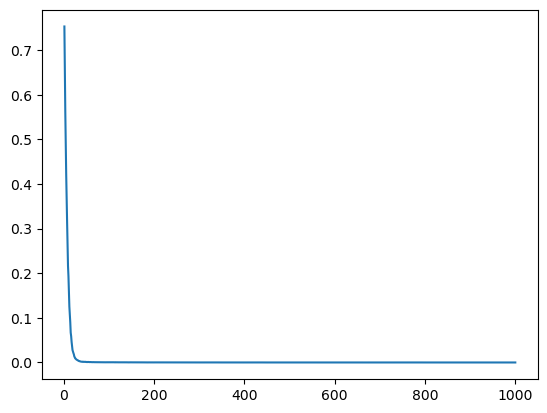

In [130]:
# Plot mean loss per epoch 
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, epochs+1), avg_train_loss, label='Training loss')
ax.plot(range(1, epochs+1), avg_val_loss, label='Validation loss')
ax.plot(range(1, epochs+1), training_avg_acc, label='Training accuracy (%)')
ax.plot(range(1, epochs+1), val_avg_acc, label='Validation accuracy (%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / % Accuracy')
ax.set_title('Training, Validation Loss, % Accuracy')
ax.set_xlim(0, epochs+1)

ax.legend()
plt.show()


In [64]:
# # Convert dictionaries to numpy arrays
# training_loss_array = np.array(list(training_loss_dict.values()))
# val_loss_array = np.array(list(val_loss_dict.values()))
# training_acc_array = np.array(list(acc_dict.values()))
# val_acc_array = np.array(list(val_acc_dict.values()))

# # Plot loss per fold by epoch 
# fig = plt.figure()
# ax = fig.add_subplot(1, 1, 1)
# for fold in range(0, training_loss_array.shape[0]):
#     ax.plot(range(1, epochs+1), training_loss_array[fold], label='Training loss', color='b')
# for fold in range(0, val_loss_array.shape[0]):
#     ax.plot(range(1, epochs+1), val_loss_array[fold], label='Validation loss', color='orange')
# for fold in range(0, training_acc_array.shape[0]):
#     ax.plot(range(1, epochs+1), training_acc_array[fold], label='Training accuracy (%)', color='g')
# for fold in range(0, val_acc_array.shape[0]): 
#     ax.plot(range(1, epochs+1), val_acc_array[fold], label='Validation accuracy (%)', color='r')

# ax.set_xlabel('Epoch')
# ax.set_ylabel('Loss / % Accuracy')
# ax.set_title('Training, Validation Loss, % Accuracy')
# ax.set_xlim(0, epochs+1)
# # ax.set_ylim(0.5, 1.0) 
# # ax.legend(loc='right')
# plt.show()

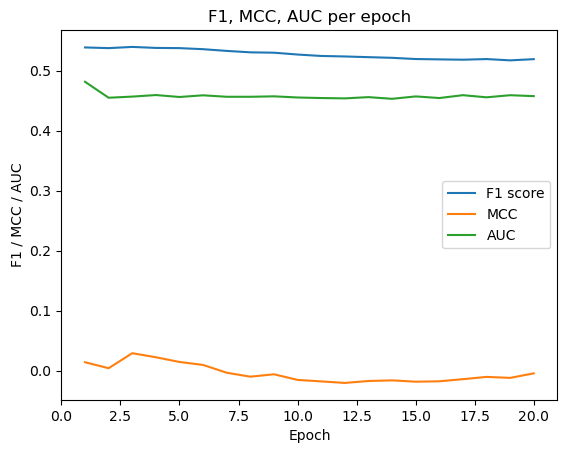

In [105]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, epochs+1), avg_f1, label='F1 score')
ax.plot(range(1, epochs+1), avg_mcc, label='MCC')
ax.plot(range(1, epochs+1), avg_auc, label='AUC')
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 / MCC / AUC')
ax.set_title('F1, MCC, AUC per epoch')
ax.set_xlim(0, epochs+1)

ax.legend()
plt.show()
